In [1]:
pip install pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import sqlite3

In [3]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [5]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')


In [6]:
sales_data = [
    ("Pen", 10, 2.5),
    ("Notebook", 5, 3.0),
    ("Pencil", 20, 1.0),
    ("Eraser", 8, 0.5),
    ("Notebook", 3, 3.0),
    ("Pen", 7, 2.5),
]

In [7]:
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)
conn.commit()
conn.close()

Sales Summary:
    product  total_qty  revenue
0    Eraser          8      4.0
1  Notebook          8     24.0
2       Pen         17     42.5
3    Pencil         20     20.0


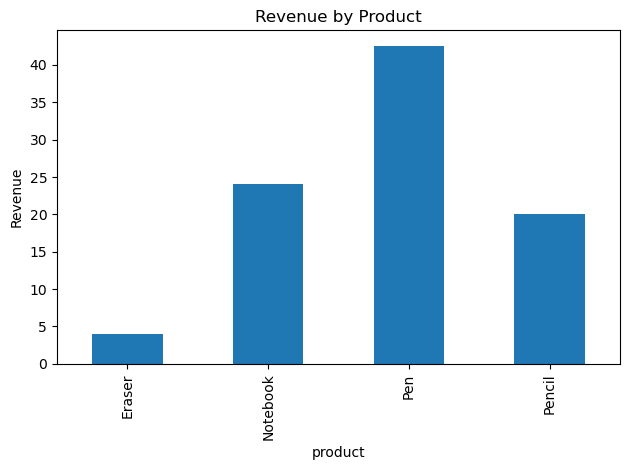

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sales_data.db")


query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""


df = pd.read_sql_query(query, conn)


print("Sales Summary:")
print(df)


df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', legend=False)
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()


conn.close()
